## Imports and GPU selection

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
import torch 
import gymnasium as gym
import mani_skill.envs
from mani_skill.vector.wrappers.gymnasium import ManiSkillVectorEnv
from tqdm import tqdm
import pandas as pd
import time

import sys
sys.path.append('../scripts')
from ppo import PPO
from animate_frames import animate_frames

# Check for GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    raise RuntimeError('No GPU found')

c:\Users\CKW09\OneDrive\Documents\Duke Stuff\2026 - Spring\CS 372\CS372_Robot_Arm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\CKW09\OneDrive\Documents\Duke Stuff\2026 - Spring\CS 372\CS372_Robot_Arm\.venv\Lib\site-packages\sapien\wrapper\pinocchio_model.py:299: UserWarning: pinnochio package is not installed, robotics functionalities will not be available
  warnings.warn(


RuntimeError: No GPU found

## Model Training

### Training Loop

In [ ]:
# Initialize model and environment
batch_size = 128
env = gym.make(
    "PickCube-v1",
    num_envs=batch_size,
    obs_mode="state", 
    control_mode="pd_joint_delta_pos", 
    render_mode=None,
    robot_uids="so100", 
    max_episode_steps=100
)
env = ManiSkillVectorEnv(env, auto_reset=False, ignore_terminations=False)

model = PPO(device, env, load_parameters=False, std=.3, actor_lr=1e-3, critic_lr=5e-3, clip=.1, time_penalty=1, success_bonus=10.0)

# Model training
model.train(num_batches=1_000, patience=None, save_freq=10)

Training model: 100%|██████████| 100/100 [01:54<00:00,  1.15s/it]


### Plot Training Data

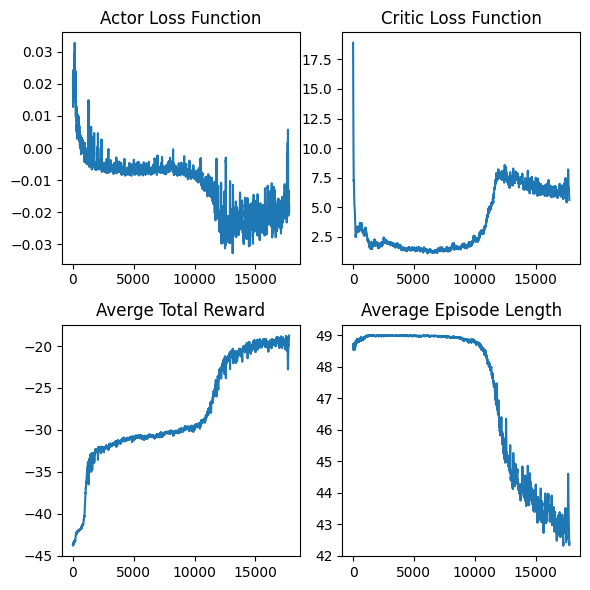

In [22]:
df = pd.read_csv(model.training_data_path)
actor_losses = df['Actor Losses'].to_numpy()
critic_losses = df['Critic Losses'].to_numpy()
total_rewards = df['Total Rewards'].to_numpy()
avg_lengths = df['Avg Lengths'].to_numpy()

smoothing = 25
fig, axs = plt.subplots(2, 2, num=1, clear=True, figsize = (6, 6))
axs[0, 0].plot(np.convolve(actor_losses, np.ones(smoothing), 'valid') / smoothing)
axs[0, 0].set(title='Actor Loss Function')
axs[0, 1].plot(np.convolve(critic_losses, np.ones(smoothing), 'valid') / smoothing)
axs[0, 1].set(title='Critic Loss Function')
axs[1, 0].plot(np.convolve(total_rewards, np.ones(smoothing), 'valid') / smoothing)
axs[1, 0].set(title='Averge Total Reward')
axs[1, 1].plot(np.convolve(avg_lengths, np.ones(smoothing), 'valid') / smoothing)
axs[1, 1].set(title='Average Episode Length')
fig.tight_layout()
fig.show()

## Evaluation

### Qualitative

In [23]:

# Initialize model and environment 
batch_size = 16
env = gym.make(
    "PickCube-v1", # there are more tasks e.g. "PushCube-v1", "PegInsertionSide-v1", ...
    num_envs=batch_size,
    obs_mode="state", # there is also "state_dict", "rgbd", ...
    control_mode="pd_joint_delta_pos", 
    render_mode="rgb_array",
    robot_uids="so100"
)
env = ManiSkillVectorEnv(env, auto_reset=False, ignore_terminations=False)

model = PPO(device, env, load_parameters=True)

# Run model
batch_frames = model.run_batch(render=True)[-1]

# Create animation of simulation results
ani = animate_frames(batch_frames)
display(HTML(ani.to_html5_video()))

### Success Rate

In [24]:
# Initialize model and environment 
batch_size = 128
env = gym.make(
    "PickCube-v1", # there are more tasks e.g. "PushCube-v1", "PegInsertionSide-v1", ...
    num_envs=batch_size,
    obs_mode="state", # there is also "state_dict", "rgbd", ...
    control_mode="pd_joint_delta_pos", 
    render_mode=None,
    robot_uids="so100"
)
env = ManiSkillVectorEnv(env, auto_reset=False, ignore_terminations=False)

model = PPO(device, env, load_parameters=True)

# Run model
batch_successes = model.run_batch(render=False)[-2]

# Determine success rate
success_rate = (batch_successes.sum()/batch_successes.numel()).item()
print(f'Model success rate: {success_rate:.3f}')

Model success rate: 0.961


### Inference Time

In [25]:
# Initialize model and environment 
batch_size = 4
env = gym.make(
    "PickCube-v1", # there are more tasks e.g. "PushCube-v1", "PegInsertionSide-v1", ...
    num_envs=batch_size,
    obs_mode="state", # there is also "state_dict", "rgbd", ...
    control_mode="pd_joint_delta_pos", 
    render_mode=None,
    robot_uids="so100"
)
env = ManiSkillVectorEnv(env, auto_reset=False, ignore_terminations=False)

model = PPO(device, env, load_parameters=True)

# Evaluate average inference time
total_time = 0.0
n = 1_000
for _ in range(n):
    obs = torch.tensor(env.observation_space.sample(), device=device)
    start_time = time.perf_counter()
    _ = model.get_action(obs)
    end_time = time.perf_counter()
    total_time += end_time - start_time
avg_time = total_time/n
print(f'Average inference time: {avg_time*1e3:.3f} ms')

Average inference time: 0.746 ms
